# Simulation Exploration

Thin notebook for inspecting a completed simulation run bundle.

Design rule:
- keep analysis logic in `libs.plotting.simulation_artifacts`
- keep this notebook limited to loading, selecting, and displaying existing helpers


## Setup

Select a run directory explicitly, or leave `RUN_DIR = None` to pick the latest bundle under `data/simulation_runs`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from libs.plotting import (
    SensorExplorerState,
    artifact_availability_table,
    build_parameter_explorer_figure,
    load_explorer_bundle,
    load_explorer_filter_options,
    load_explorer_slice,
    discover_latest_run_dir,
    extract_log_records,
    load_artifact_table,
    load_simulation_run_bundle,
    plot_anomaly_summary,
    plot_fleet_structure,
    plot_flight_timelines,
    plot_hierarchy_behavior_map,
    plot_hierarchy_datatype_map,
    plot_hierarchy_overview,
    plot_hierarchy_structure,
    plot_phase_confidence,
    plot_phase_timelines,
    plot_phase_overview,
    plot_score_distribution,
    plot_stage_timings,
    plot_validation_status,
    validation_summary_table,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "libs").exists() and (REPO_ROOT.parent / "libs").exists():
    REPO_ROOT = REPO_ROOT.parent

BASE_DIR = REPO_ROOT / "data" / "simulation_runs"
RUN_DIR: str | None = None

run_dir = Path(RUN_DIR).resolve() if RUN_DIR else discover_latest_run_dir(BASE_DIR)
bundle = load_simulation_run_bundle(run_dir)
full_run_report_path = bundle.paths.reports_dir / "full_run_report.json"
full_run_report = json.loads(full_run_report_path.read_text(encoding="utf-8")) if full_run_report_path.exists() else None

print(f"run_dir: {bundle.paths.run_dir}")
print(f"missing_files: {len(bundle.missing_files)}")


run_dir: /home/jrs/code/S3NTINEL/sentinel/data/simulation_runs/20260318T004935Z_power_pressurization_hierarchy_composite
missing_files: 0


## Run Summary

In [2]:
manifest = bundle.manifest or {}
pipeline_meta = manifest.get("pipeline", {}) if isinstance(manifest.get("pipeline"), dict) else {}
timing_meta = manifest.get("timing", {}) if isinstance(manifest.get("timing"), dict) else {}
stage_rows = bundle.pipeline_summary.get("stages", []) if isinstance(bundle.pipeline_summary, dict) else []
display(pd.DataFrame([{
    "run_dir": str(bundle.paths.run_dir),
    "status": manifest.get("status"),
    "pipeline_mode": pipeline_meta.get("mode") or pipeline_meta.get("name"),
    "completed_stages": sum(1 for row in stage_rows if str(row.get("status")) == "success"),
    "failed_stages": sum(1 for row in stage_rows if str(row.get("status")) == "failed"),
    "elapsed_seconds": timing_meta.get("elapsed_ms", 0) / 1000.0 if timing_meta.get("elapsed_ms") is not None else None,
}]))

if full_run_report is not None:
    display(Markdown("### Modeling Performance"))
    display(pd.json_normalize(full_run_report.get("modeling_performance", {}), sep="."))
    display(Markdown("### Engineering Performance"))
    display(pd.json_normalize(full_run_report.get("engineering_performance", {}), sep="."))


,run_dir,status,pipeline_mode,completed_stages,failed_stages,elapsed_seconds
0,/home/jrs/code/S3NTINEL/sentinel/data/simulati...,success,full,10,0,1576.020713


## Stage and Validation Views

,artifact_name,exists,path
0,anomaly_event_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
1,anomaly_telemetry_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
2,anomaly_window_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
3,backbone,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
4,backbone_sensor_energy,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
5,continuous_scaling_profile,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
6,coupling_misbehavior_windows,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
7,event_graph,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
8,events,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
9,fused_graph,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...


,report_name,status,summary
0,profile_validation_summary,ok,
1,event_validation_summary,ok,
2,label_contract_summary,ok,
3,phase_validation_summary,ok,
4,hierarchy_validation_summary,ok,
5,coupling_validation_summary,ok,
6,score_validation_summary,ok,
7,misbehavior_score_validation_summary,ok,
8,misbehavior_window_validation_summary,ok,
9,misbehavior_attribution_validation_summary,ok,


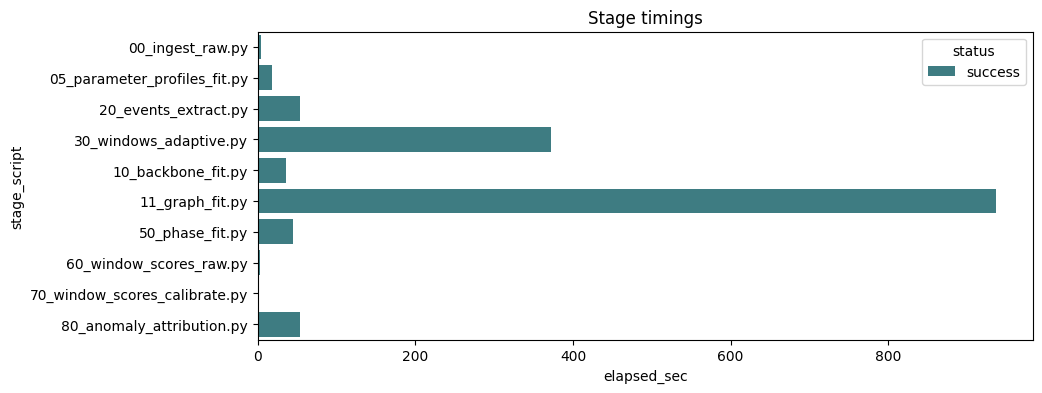

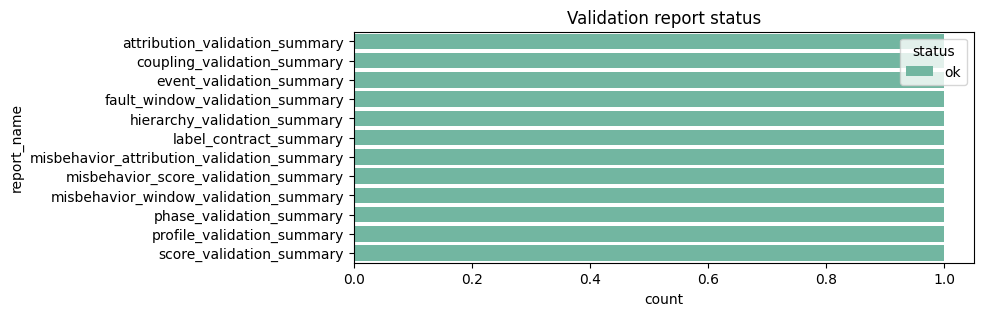

In [3]:
display(artifact_availability_table(bundle))
display(validation_summary_table(bundle))

stage_fig = plot_stage_timings(bundle)
if stage_fig is not None:
    display(stage_fig)
    plt.close(stage_fig)

validation_fig = plot_validation_status(bundle)
if validation_fig is not None:
    display(validation_fig)
    plt.close(validation_fig)


In [ ]:
explorer_bundle = load_explorer_bundle(bundle)
fleet_dataset = load_explorer_slice(explorer_bundle, SensorExplorerState())
fleet_telemetry_df = fleet_dataset["telemetry"]

for fig in [
    plot_fleet_structure(fleet_telemetry_df),
    plot_flight_timelines(fleet_telemetry_df),
]:
    if fig is not None:
        display(fig)
        if hasattr(fig, "number"):
            plt.close(fig)


## High-Level Plots

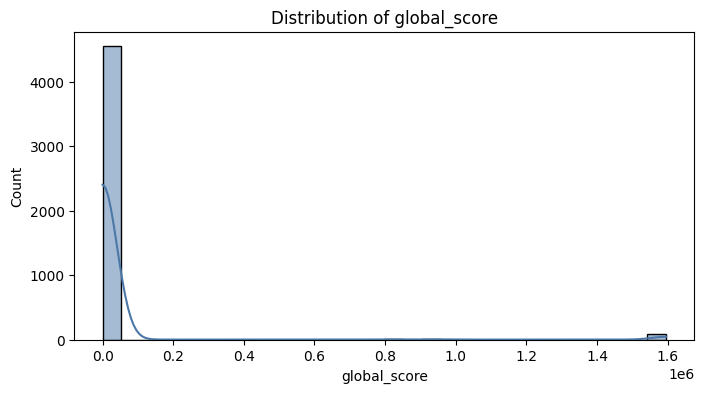

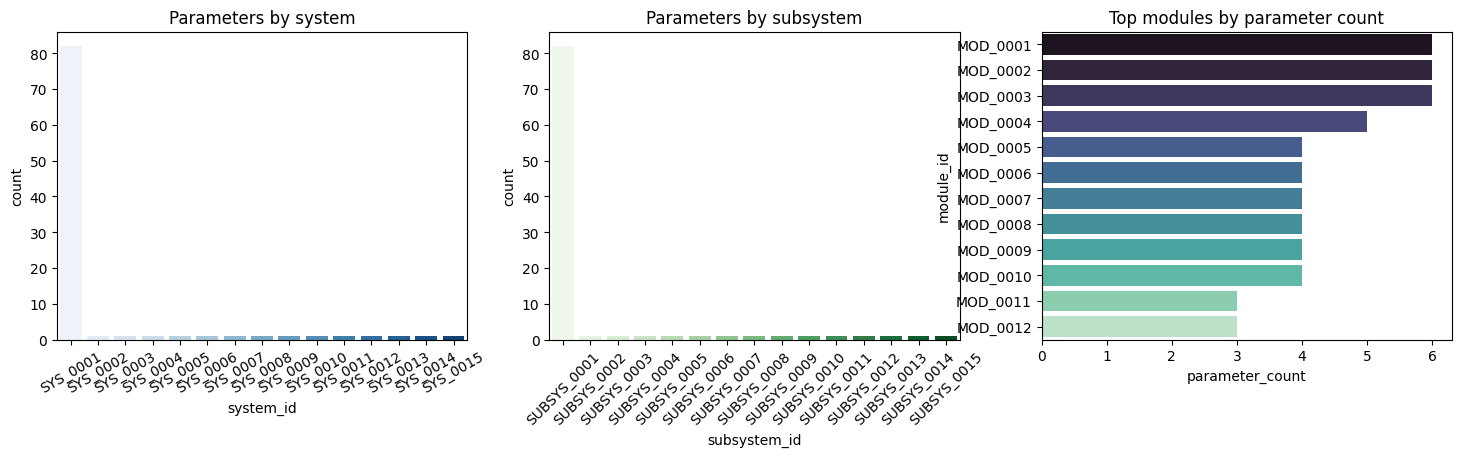

In [4]:
score_df = load_artifact_table(bundle, "window_scores_calibrated") if "window_scores_calibrated" in bundle.artifact_inventory else pd.DataFrame()
anomaly_df = load_artifact_table(bundle, "anomaly_attribution") if "anomaly_attribution" in bundle.artifact_inventory else pd.DataFrame()

for df, plot_fn in [
    (score_df, plot_score_distribution),
    (anomaly_df, plot_anomaly_summary),
]:
    fig = plot_fn(df)
    if fig is not None:
        display(fig)
        plt.close(fig)


In [ ]:
hierarchy_df = load_artifact_table(bundle, "hierarchy_sensor_map") if "hierarchy_sensor_map" in bundle.artifact_inventory else pd.DataFrame()
behavior_profile_df = load_artifact_table(bundle, "parameter_behavior_profile") if "parameter_behavior_profile" in bundle.artifact_inventory else pd.DataFrame()

for fig in [
    plot_hierarchy_overview(hierarchy_df),
    plot_hierarchy_structure(hierarchy_df),
    plot_hierarchy_behavior_map(hierarchy_df, behavior_profile_df),
    plot_hierarchy_datatype_map(hierarchy_df, behavior_profile_df),
]:
    if fig is not None:
        display(fig)
        if hasattr(fig, "number"):
            plt.close(fig)


In [ ]:
phase_df = load_artifact_table(bundle, "phase_windows") if "phase_windows" in bundle.artifact_inventory else pd.DataFrame()

for fig in [
    plot_phase_overview(phase_df),
    plot_phase_timelines(phase_df),
    plot_phase_confidence(phase_df),
]:
    if fig is not None:
        display(fig)
        if hasattr(fig, "number"):
            plt.close(fig)


## Parameter Explorer Example

Pick one or more parameters from the prepared dataset and render the canonical figure.

In [ ]:
explorer_bundle = load_explorer_bundle(bundle)
filter_options = load_explorer_filter_options(explorer_bundle)
available_parameters = filter_options["parameter_names"]
DEFAULT_PARAMETERS = tuple(available_parameters[: min(3, len(available_parameters))])

display(pd.DataFrame({"parameter_name": available_parameters}).head(20))

state = SensorExplorerState(parameter_names=DEFAULT_PARAMETERS)
dataset = load_explorer_slice(explorer_bundle, state)
explorer_fig = build_parameter_explorer_figure(dataset, state)
if explorer_fig is not None:
    display(explorer_fig)
    plt.close(explorer_fig)


,parameter_name
0,actuator_load_pct
1,actuator_load_pct_b2
2,actuator_load_pct_b3
3,actuator_load_pct_b4
4,actuator_position_pct
5,actuator_position_pct_b2
6,actuator_position_pct_b3
7,actuator_position_pct_b4
8,aircraft_altitude_ft
9,aircraft_altitude_ft_b2


## Recent Log Records

In [ ]:
log_df = extract_log_records(bundle.log_text)
display(log_df.tail(50))


: 